# 02 - Exploratory Data Analysis

## Goal
In this notebook, we explore the medical appointment no-show dataset in more

In [1]:
import pandas as pd

df = pd.read_csv("../data/medical-appointments-no-show-en.csv")
df.head(10)

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,date_of_birth,entry_service_date,city,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,09/09/2021,yes,surto,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,09/09/2021,no,NaN,motor,10/10/1954,5/2/2020,B. CAMBORIU,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild
5,occupational therapy,14:00,M,09/09/2021,no,NaN,intellectual,21/3/2017,26/11/2019,ITAJAÍ,...,0,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild
6,psychotherapy,14:00,M,09/09/2021,no,NaN,intellectual,10/1/2011,1/10/2019,CAMBORIU,...,0,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild
7,psychotherapy,14:00,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
8,occupational therapy,14:00,M,09/09/2021,no,NaN,intellectual,21/3/2017,20/11/2019,ITAJAÍ,...,0,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild
9,speech therapy,14:00,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild


In [2]:
import matplotlib.pyplot as plt

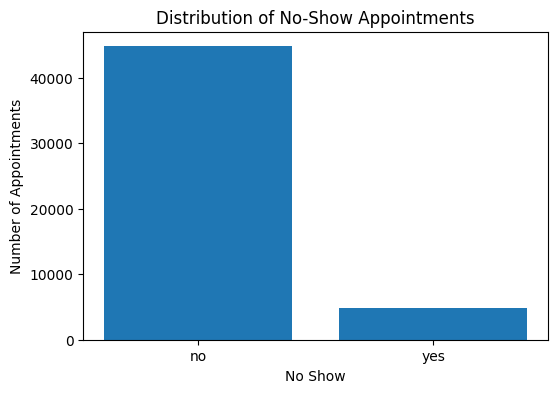

In [3]:
no_show_counts = df["no_show"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(no_show_counts.index, no_show_counts.values)

plt.title("Distribution of No-Show Appointments")
plt.xlabel("No Show")
plt.ylabel("Number of Appointments")

plt.show()

### Observation

The target variable is highly imbalanced. Most appointments are completed, while only a relatively small share of appointments result in a no-show.

This means that the problem should be treated as an **imbalanced classification task**. During modeling, relying only on accuracy may be misleading, since a model predicting the majority class most of the time could still appear to perform well.

In [4]:
shift_no_show_rate = (
    df.groupby("appointment_shift")["no_show"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

shift_no_show_rate

appointment_shift
afternoon    9.912076
morning      9.526878
Name: no_show, dtype: float64

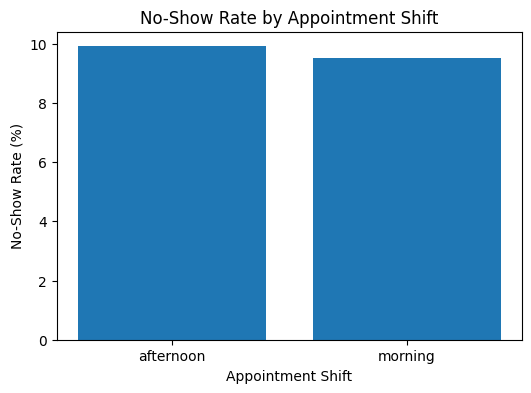

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(shift_no_show_rate.index, shift_no_show_rate.values)

plt.title("No-Show Rate by Appointment Shift")
plt.xlabel("Appointment Shift")
plt.ylabel("No-Show Rate (%)")

plt.show()

In [6]:
heat_summary = (
    df.groupby("heat_intensity")["no_show"]
    .agg(
        total_appointments="count",
        no_show_count=lambda x: (x == "yes").sum(),
        no_show_rate=lambda x: (x == "yes").mean() * 100
    )
    .sort_values("no_show_rate", ascending=False)
)

heat_summary["no_show_rate"] = heat_summary["no_show_rate"].round(2)

heat_summary

,total_appointments,no_show_count,no_show_rate
heat_intensity,,,
heavy_cold,1486,213,14.33
heavy_warm,511,58,11.35
warm,9890,1091,11.03
cold,14293,1492,10.44
mild,23413,1978,8.45


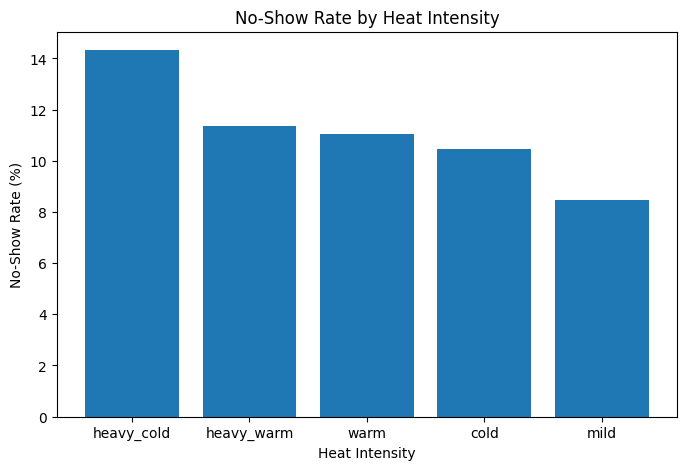

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(heat_summary.index, heat_summary["no_show_rate"])

plt.title("No-Show Rate by Heat Intensity")
plt.xlabel("Heat Intensity")
plt.ylabel("No-Show Rate (%)")

plt.show()

### Observation

No-show rates vary noticeably across heat intensity categories.  
Appointments scheduled on **heavy cold** days have the highest no-show rate, while **mild** days show the lowest rate.

This suggests that more extreme temperature conditions, especially severe cold, may be associated with a higher likelihood of missed appointments.

In [8]:
rain_summary = (
    df.groupby("rain_intensity")["no_show"]
    .agg(
        total_appointments="count",
        no_show_count=lambda x: (x == "yes").sum(),
        no_show_rate=lambda x: (x == "yes").mean() * 100
    )
    .sort_values("no_show_rate", ascending=False)
)

rain_summary["no_show_rate"] = rain_summary["no_show_rate"].round(2)

rain_summary

,total_appointments,no_show_count,no_show_rate
rain_intensity,,,
heavy,2444,256,10.47
moderate,6985,723,10.35
weak,4802,473,9.85
no_rain,35362,3380,9.56


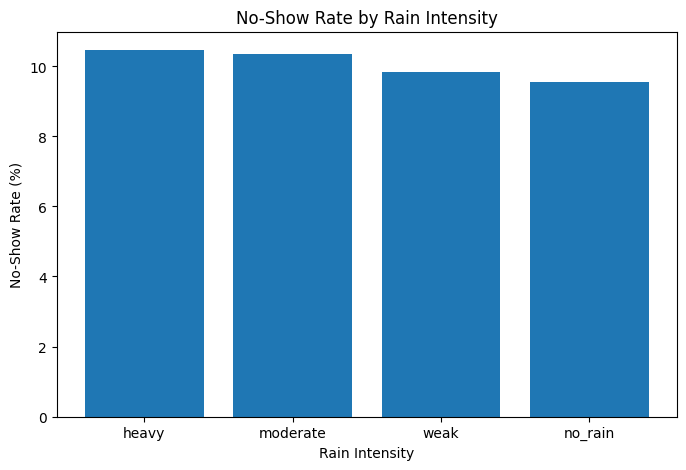

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(rain_summary.index, rain_summary["no_show_rate"])

plt.title("No-Show Rate by Rain Intensity")
plt.xlabel("Rain Intensity")
plt.ylabel("No-Show Rate (%)")

plt.show()

### Observation

No-show rates increase slightly as rain intensity becomes stronger.  
Appointments scheduled on days with **

In [10]:
df["specialty_missing"] = df["specialty"].isna()
df["city_missing"] = df["city"].isna()
df["disability_missing"] = df["disability"].isna() | (df["disability"] == "")

In [11]:
specialty_missing_summary = (
    df.groupby("specialty_missing")["no_show"]
    .agg(
        total_appointments="count",
        no_show_count=lambda x: (x == "yes").sum(),
        no_show_rate=lambda x: (x == "yes").mean() * 100
    )
)

specialty_missing_summary["no_show_rate"] = specialty_missing_summary["no_show_rate"].round(2)

specialty_missing_summary

,total_appointments,no_show_count,no_show_rate
specialty_missing,,,
False,42139,3931,9.33
True,7454,901,12.09


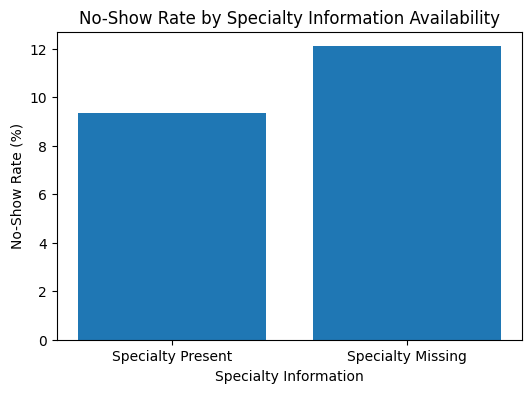

In [12]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["Specialty Present", "Specialty Missing"],
    specialty_missing_summary["no_show_rate"]
)

plt.title("No-Show Rate by Specialty Information Availability")
plt.xlabel("Specialty Information")
plt.ylabel("No-Show Rate (%)")

plt.show()

### Observation

Appointments with missing specialty information show a higher no-show rate (**12.09%**) compared to appointments where specialty information is available (**9.33%**).

This may indicate that incomplete appointment records are associated with a higher risk of missed appointments, making data completeness itself a potentially meaningful signal.

In [13]:
missing_cols = ["specialty_missing", "city_missing", "disability_missing"]

missingness_summary = []

for col in missing_cols:
    temp = (
        df.groupby(col)["no_show"]
        .agg(
            total_appointments="count",
            no_show_count=lambda x: (x == "yes").sum(),
            no_show_rate=lambda x: (x == "yes").mean() * 100
        )
        .reset_index()
    )
    
    temp["feature"] = col.replace("_missing", "")
    temp["status"] = temp[col].map({False: "Present", True: "Missing"})
    
    missingness_summary.append(temp[["feature", "status", "total_appointments", "no_show_count", "no_show_rate"]])

missingness_summary = pd.concat(missingness_summary, ignore_index=True)
missingness_summary["no_show_rate"] = missingness_summary["no_show_rate"].round(2)

missingness_summary

,feature,status,total_appointments,no_show_count,no_show_rate
0,specialty,Present,42139,3931,9.33
1,specialty,Missing,7454,901,12.09
2,city,Present,44412,4048,9.11
3,city,Missing,5181,784,15.13
4,disability,Present,44456,4054,9.12
5,disability,Missing,5137,778,15.15


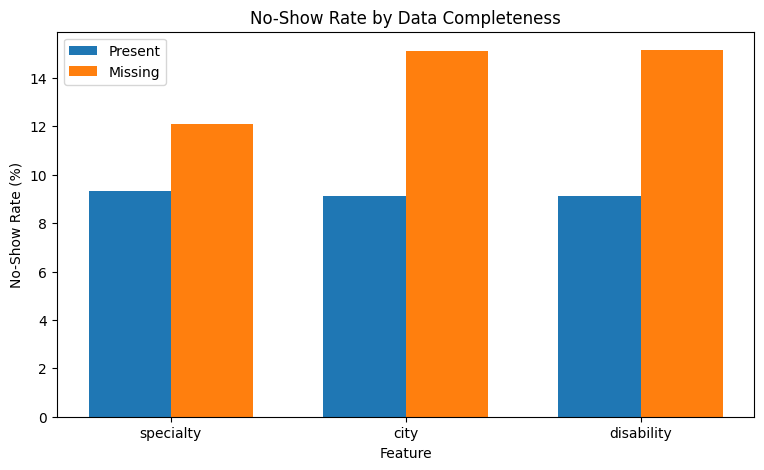

In [14]:
import numpy as np

features = ["specialty", "city", "disability"]

present_rates = (
    missingness_summary[missingness_summary["status"] == "Present"]
    .set_index("feature")
    .loc[features, "no_show_rate"]
)

missing_rates = (
    missingness_summary[missingness_summary["status"] == "Missing"]
    .set_index("feature")
    .loc[features, "no_show_rate"]
)

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, present_rates, width, label="Present")
plt.bar(x + width/2, missing_rates, width, label="Missing")

plt.title("No-Show Rate by Data Completeness")
plt.xlabel("Feature")
plt.ylabel("No-Show Rate (%)")
plt.xticks(x, features)
plt.legend()

plt.show()

### Observation

Missing information appears to be associated with higher no-show rates across multiple appointment-related variables.

- Missing `specialty` information: **12.09%** no-show rate
- Missing `city` information: **15.13%** no-show rate
- Missing `disability` information: **15.15%** no-show rate

In contrast, appointments with these fields present show no-show rates close to **9%**.  
This suggests that **data completeness itself may be a meaningful signal** in understanding and predicting missed appointments.

In [16]:
df["appointment_date"] = pd.to_datetime(
    df["appointment_date"],
    dayfirst=True
)

df["appointment_day_of_week"] = df["appointment_date"].dt.day_name()

df[["appointment_date", "appointment_day_of_week"]].head()

,appointment_date,appointment_day_of_week
0,2021-09-09,Thursday
1,2021-09-09,Thursday
2,2021-09-09,Thursday
3,2021-09-09,Thursday
4,2021-09-09,Thursday


In [17]:
day_summary = (
    df.groupby("appointment_day_of_week")["no_show"]
    .agg(
        total_appointments="count",
        no_show_count=lambda x: (x == "yes").sum(),
        no_show_rate=lambda x: (x == "yes").mean() * 100
    )
)

day_summary["no_show_rate"] = day_summary["no_show_rate"].round(2)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_summary = day_summary.reindex([day for day in day_order if day in day_summary.index])

day_summary

,total_appointments,no_show_count,no_show_rate
appointment_day_of_week,,,
Monday,9991,1032,10.33
Tuesday,10274,903,8.79
Wednesday,9624,900,9.35
Thursday,8270,753,9.11
Friday,10133,1110,10.95
Saturday,719,71,9.87
Sunday,582,63,10.82


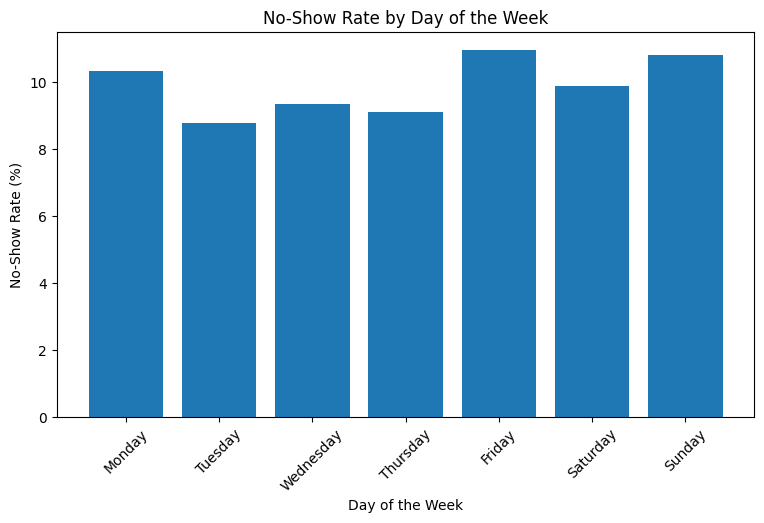

In [18]:
plt.figure(figsize=(9, 5))
plt.bar(day_summary.index, day_summary["no_show_rate"])

plt.title("No-Show Rate by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45)

plt.show()

### Observation

No-show rates vary across the days of the week.  
Friday shows the highest no-show rate among high-volume appointment days (**10.95%**), followed by Monday (**10.33%**). Tuesday has the lowest observed rate (**8.79%**).

Weekend rates should be interpreted cautiously due to the relatively small number of appointments scheduled on Saturday and Sunday.

In [19]:
df["age"].describe()

count    39243.000000
mean        18.522361
std         19.234999
min          2.000000
25%          8.000000
50%         11.000000
75%         15.000000
max        110.000000
Name: age, dtype: float64

In [20]:
df["age"].sort_values().head(10)

32386    2.0
7404     2.0
32382    2.0
42646    2.0
42642    2.0
19666    2.0
19670    2.0
2716     2.0
44470    2.0
44466    2.0
Name: age, dtype: float64

In [21]:
df["age"].sort_values(ascending=False).head(10)

29520    110.0
23305    110.0
19185    110.0
19180    110.0
31775    110.0
2151     110.0
31770    110.0
13616    110.0
13421    110.0
43325    110.0
Name: age, dtype: float64

In [22]:
df["age"].value_counts().sort_index().tail(15)

age
75.0      25
76.0      12
77.0      72
78.0      25
79.0      34
80.0     182
81.0      94
82.0      55
83.0      54
86.0      14
87.0      58
91.0      34
106.0     44
108.0     20
110.0     20
Name: count, dtype: int64

In [23]:
df[df["age"] >= 90]["age"].value_counts().sort_index()

age
91.0     34
106.0    44
108.0    20
110.0    20
Name: count, dtype: int64

### Age Distribution - Initial Note

The dataset is heavily concentrated around children and adolescents.  
The median age is **11**, and 75% of recorded ages are **15 or younger**.

A small number of very high age values are present, including repeated observations at ages **106**, **108**, and **110**. These values may require further investigation during preprocessing, as they could represent unusual but valid observations or potential data quality issues.

In [24]:
age_bins = [0, 5, 12, 18, 35, 60, float("inf")]
age_labels = ["2-5", "6-12", "13-18", "19-35", "36-60", "61+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

age_group_summary = (
    df.groupby("age_group", observed=False)["no_show"]
    .agg(
        total_appointments="count",
        no_show_count=lambda x: (x == "yes").sum(),
        no_show_rate=lambda x: (x == "yes").mean() * 100
    )
)

age_group_summary["no_show_rate"] = age_group_summary["no_show_rate"].round(2)

age_group_summary

,total_appointments,no_show_count,no_show_rate
age_group,,,
2-5,1637,255,15.58
6-12,21793,1805,8.28
13-18,8210,663,8.08
19-35,1667,168,10.08
36-60,2719,286,10.52
61+,3217,317,9.85


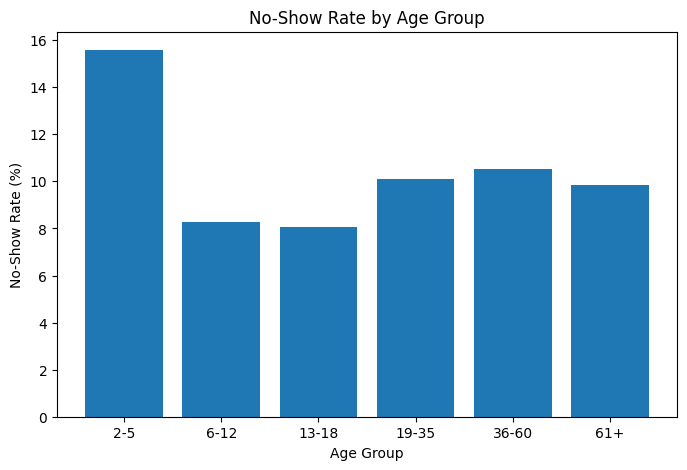

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(age_group_summary.index.astype(str), age_group_summary["no_show_rate"])

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")

plt.show()

### Observation

No-show rates vary meaningfully across age groups.  
The **2–5 age group** shows the highest no-show rate (**15.58%**), while the **6–12** and **13–18** groups have notably lower rates, both close to **8%**.

This suggests that grouping all children under 12 together may hide important differences in appointment attendance behavior.

In [26]:
specialty_summary = (
    df.groupby("specialty", dropna=False)["no_show"]
    .agg(
        total_appointments="count",
        no_show_count=lambda x: (x == "yes").sum(),
        no_show_rate=lambda x: (x == "yes").mean() * 100
    )
    .sort_values("no_show_rate", ascending=False)
)

specialty_summary["no_show_rate"] = specialty_summary["no_show_rate"].round(2)

specialty_summary

,total_appointments,no_show_count,no_show_rate
specialty,,,
sem especialidade,57,13,22.81
NaN,7454,901,12.09
physiotherapy,9074,941,10.37
speech therapy,11877,1121,9.44
psychotherapy,11675,1091,9.34
occupational therapy,6486,555,8.56
pedagogo,2064,154,7.46
assist,194,13,6.70
enf,712,43,6.04


In [28]:
specialty_plot = specialty_summary.copy()

specialty_plot = specialty_plot[
    specialty_plot["total_appointments"] >= 500
].copy()

specialty_plot = specialty_plot.rename(
    index={pd.NA: "Missing", None: "Missing"}
)

specialty_plot.index = specialty_plot.index

In [29]:
specialty_plot = specialty_summary[
    specialty_summary["total_appointments"] >= 500
].copy()

specialty_plot = specialty_plot.reset_index()

specialty_plot["specialty"] = specialty_plot["specialty"].fillna("Missing")

specialty_plot

,specialty,total_appointments,no_show_count,no_show_rate
0,Missing,7454,901,12.09
1,physiotherapy,9074,941,10.37
2,speech therapy,11877,1121,9.44
3,psychotherapy,11675,1091,9.34
4,occupational therapy,6486,555,8.56
5,pedagogo,2064,154,7.46
6,enf,712,43,6.04


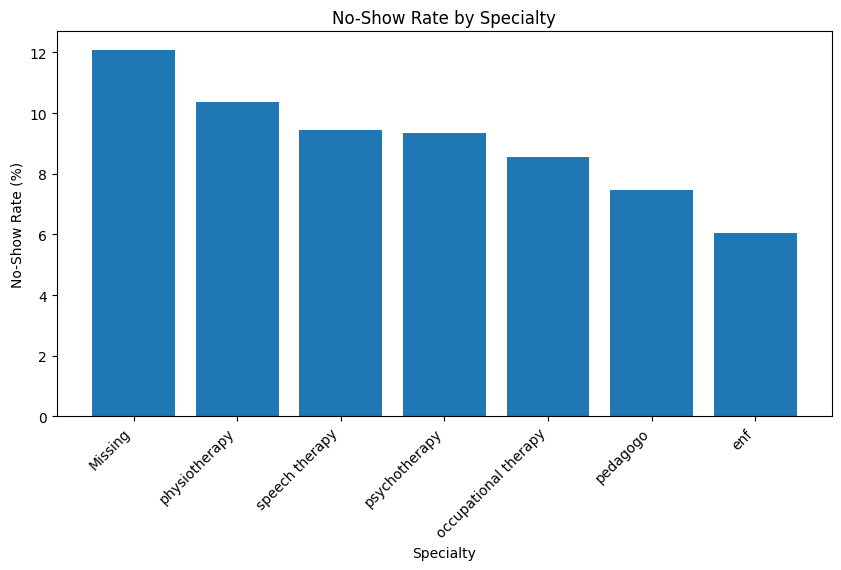

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(
    specialty_plot["specialty"],
    specialty_plot["no_show_rate"]
)

plt.title("No-Show Rate by Specialty")
plt.xlabel("Specialty")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

### Observation

No-show rates vary across specialties.  
Among specialties with a sufficient number of appointments, **physiotherapy** shows the highest no-show rate (**10.37%**).

Appointments with **missing specialty information** have an even higher no-show rate (**12.09%**), reinforcing the earlier observation that incomplete appointment records may be associated with missed visits.

## EDA Summary

This exploratory analysis revealed several patterns that may help explain and predict medical appointment no-shows:

- The target variable is imbalanced: approximately **9.74%** of appointments are no-shows.
- Weather conditions appear to matter:
  - **Heavy cold** days show the highest no-show rate (**14.33%**).
  - No-show rates increase slightly as **rain intensity** becomes stronger.
- Data completeness is strongly associated with attendance:
  - Missing `specialty`, `city`, and `disability` information all correspond to noticeably higher no-show rates.
- Timing may play a role:
  - **Friday** has the highest no-show rate among high-volume weekdays (**10.95%**).
  - **Tuesday** has the lowest observed rate (**8.79%**).
- Age groups behave differently:
  - The **2–5 age group** has a particularly high no-show rate (**15.58%**).
  - This shows that broader child age categories can hide meaningful variation.
- Specialty also matters:
  - Among sufficiently large specialty groups, **physiotherapy** has the highest no-show rate (**10.37%**).
  - Missing specialty information remains one of the strongest observed signals.

These findings suggest that no-show risk may be influenced by a combination of:
1. **External conditions** such as weather,
2. **Operational/data quality factors** such as missing appointment information,
3. **Patient characteristics** such as age,
4. **Scheduling and service-related factors** such as weekday and specialty.

The next step is to move into **preprocessing**, where we will prepare the dataset for modeling, handle missing values carefully, engineer useful features, and remove variables that may cause data leakage.